<a href="https://colab.research.google.com/github/anabelpoulard13-boop/ensight_concentration_analysis/blob/main/concentration_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Concentration Analysis

The following code performs a concentration analysis on a `.csv` file with the absorbance measurements from EnSight plate reader.

It takes the raw `.csv` and, using key information provided at the start, estimates the cell growth function and applies it to all wells in the plate. It then cleans the data to keep only relevant growth and outputs an Excel table along with a list of wells showing significant growth. As a bonus, it also generates a heatmap to help visualize the relevant wells.

## Variables
The variables blank_well, sample_well, and sample_concentration must be defined before running the code. They tell the program which wells to use for the slope calculation.

- `blank_well`, is a well with no concentration but still has an absorbance value therfore it has always a value of 0.

- `sample_well`, is a well with a known sample

- `sample_concentration`, is the concentration of that sample.

In [50]:
blank_well = 'O6' # Well with no sample 0ng/ul
sample_well = 'A6' # Well with sample
sample_concentration = 100 # Sample concentration in ng/ul

### Data frame
This part of the code takes the raw data from the Ensight machine and converts it into a data frame so Python can extract and work only with the relevant data.

In [51]:
import pandas as pd
import string
import glob
import matplotlib.pyplot as plt
import numpy as np
import os

files_path = []
files_path = glob.glob('*.csv')
file_path = files_path[0]
print(file_path)

plates_sizes = {                  # This is a disctionary of possible plate
    6 : {'rows': 2, 'cols': 3},   # size allowing the user to have different size of plate
    12 : {'rows': 3, 'cols': 4},
    24 : {'rows': 4, 'cols': 6},
    96 : {'rows': 8, 'cols': 12},
    384 : {'rows': 16, 'cols': 24}
}

df = pd.read_csv(file_path, skiprows = 9)
print(df.head())

num_cols = len(df.columns) - 2

detected_plate = None
for row, col in plates_sizes.items():
    if col['cols'] == num_cols:
        detected_plate = row
        break
if detected_plate:
    read_this = plates_sizes[detected_plate]['rows']
    print(f'✓ Detected: {detected_plate} well plate — reading {read_this} rows')
    df = pd.read_csv(file_path, skiprows=9, nrows= read_this)
else:
    print(f'✗ Unknown plate size — {num_cols} columns not in list')

table_data = df.iloc[0:read_this, 1:num_cols + 1]
row_labels = [string.ascii_uppercase[i] for i in range(len(table_data))]
table_data.insert(0, 'Row_Label', row_labels)

display(table_data)

Qubit-384 M_20260305-232733.csv
  Unnamed: 0       1        2       3      4       5      6       7      8  \
0          A   91229  1330099  173030  41631  141300  43021  193485  46062   
1          B   40307    41744   39551  40892   41356  41509   42318  44852   
2          C  123201   676441  184841  40052  134138  40012  170009  43812   
3          D   39670    41218   40313  40332   40656  39054   39924  41577   
4          E  136557   406446  151275  42298  139112  41480  134601  43908   

        9  ...     16     17     18     19     20     21     22     23     24  \
0  148706  ...  42121  46679  41474  41340  40431  43428  41040  40597  40490   
1   40424  ...  41346  44468  42720  41030  41995  39733  40074  39613  38174   
2  143825  ...  42135  42652  40011  40312  40686  39272  39104  39339  38847   
3   38999  ...  41645  42044  41039  41492  41109  41245  40005  40510  38749   
4  135577  ...  41635  43884  41406  40539  39685  40411  41406  40742  39404   

  Unnamed: 2

,Row_Label,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,A,91229,1330099,173030,41631,141300,43021,193485,46062,148706,...,40282,42121,46679,41474,41340,40431,43428,41040,40597,40490
1,B,40307,41744,39551,40892,41356,41509,42318,44852,40424,...,42670,41346,44468,42720,41030,41995,39733,40074,39613,38174
2,C,123201,676441,184841,40052,134138,40012,170009,43812,143825,...,42576,42135,42652,40011,40312,40686,39272,39104,39339,38847
3,D,39670,41218,40313,40332,40656,39054,39924,41577,38999,...,39677,41645,42044,41039,41492,41109,41245,40005,40510,38749
4,E,136557,406446,151275,42298,139112,41480,134601,43908,135577,...,41181,41635,43884,41406,40539,39685,40411,41406,40742,39404
5,F,39903,41025,39733,41998,41404,39055,39027,42428,40648,...,40182,40870,41763,40220,41475,40910,40829,41861,40836,39614
6,G,132270,242933,176220,39784,152629,40998,133823,41941,140944,...,39121,41886,41497,40829,40387,40310,40658,41154,40952,41132
7,H,42759,41521,40532,40359,39945,40585,40151,41764,40205,...,39793,43615,42834,41714,40089,41485,40281,40837,42101,40446
8,I,139155,170645,177066,42712,141421,42728,145733,42872,150938,...,43332,44013,41997,43052,42525,41498,41718,41715,41421,42201
9,J,41130,41838,42140,41122,41445,43402,42186,41900,40250,...,39357,41210,40779,40318,40662,42387,40615,40249,41341,39377


### Finding the Variable
This code looks through the data frame to find the `blank_well` and the sample_well. Once it finds them, it assigns a value of 0 ng/µL to the blank_well and `the sample_concentration` to the `sample_well`.

In [52]:
def get_well_value(df, well):
    row_label = well[0]
    col_number = int(well[1:])
    row = df[df['Row_Label'] == row_label]
    return row.iloc[0, col_number]

zero_point_value = get_well_value(table_data, blank_well)
zero_point_concentration = 0

print(f"0ng/ul standard: Measured Value = {zero_point_value}, Concentration = {zero_point_concentration}ng/ul")

point_value = get_well_value(table_data, sample_well)
point_concentration = sample_concentration

print(f"{sample_concentration}ng/ul standard: Measured Value = {point_value}, Concentration = {point_concentration}ng/ul")


0ng/ul standard: Measured Value = 44600, Concentration = 0ng/ul
100ng/ul standard: Measured Value = 43021, Concentration = 100ng/ul


### Growth calculation
This part uses the values defined earlier to calculate the slope and the y-intercept. It then defines a formula that can be applied to the rest of the cells in the data frame.

Here, the y-axis represents absorbance and the x-axis represents concentration.

In [53]:
m = (point_value - zero_point_value) / (point_concentration - zero_point_concentration)
b = zero_point_value - (m * zero_point_concentration)

print(f"Calculated slope (m): {m:.2f}")
print(f"Calculated y-intercept (b): {b:.2f}")

def calculate_concentration(measured_value):
  concentration = (2 * ((measured_value - b)/ m))
  return concentration.round(2)

Calculated slope (m): -15.79
Calculated y-intercept (b): 44600.00


### Calculation Application
This part of the code applies the formula defined earlier to all the cells in the data frame.

It then generates a linear plot showing the growth approximation based on the two given points.

Here is the data with calculated concentrations:


,Row_Label,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,A,-5906.14,-162824.45,-16267.26,376.06,-12248.26,200.00,-18858.14,-185.18,-13186.32,...,546.93,314.00,-263.33,395.95,412.92,528.06,148.45,450.92,507.03,520.58
1,B,543.76,361.75,639.52,469.66,410.89,391.51,289.04,-31.92,528.94,...,244.46,412.16,16.72,238.13,452.18,329.96,616.47,573.27,631.67,813.93
2,C,-9955.79,-80030.53,-17763.27,576.06,-11341.10,581.13,-15884.61,99.81,-12568.08,...,256.36,312.22,246.74,581.25,543.13,495.76,674.86,696.14,666.37,728.69
3,D,624.45,428.37,543.00,540.60,499.56,702.47,592.27,382.90,709.44,...,623.56,374.29,323.75,451.04,393.67,442.18,424.95,582.01,518.05,741.10
4,E,-11647.50,-45832.30,-13511.72,291.58,-11971.12,395.19,-11399.75,87.65,-11523.37,...,433.06,375.55,90.69,404.56,514.38,622.55,530.59,404.56,488.66,658.14
5,F,594.93,452.82,616.47,329.58,404.81,702.34,705.89,275.11,500.57,...,559.59,472.45,359.34,554.78,395.82,467.38,477.64,346.93,476.76,631.54
6,G,-11104.50,-25121.34,-16671.31,610.01,-13683.22,456.24,-11301.20,336.80,-12203.17,...,693.98,343.76,393.03,477.64,533.63,543.38,499.30,436.48,462.06,439.27
7,H,233.19,389.99,515.26,537.18,589.61,508.55,563.52,359.21,556.68,...,608.87,124.76,223.69,365.55,571.37,394.55,547.06,476.63,316.53,526.16
8,I,-11976.57,-15965.17,-16778.47,239.14,-12263.58,237.11,-12809.75,218.87,-13469.03,...,160.61,74.35,329.70,196.07,262.82,392.91,365.04,365.42,402.66,303.86
9,J,439.52,349.84,311.59,440.53,399.62,151.74,305.76,341.99,550.98,...,664.09,429.39,483.98,542.37,498.80,280.30,504.75,551.11,412.79,661.56


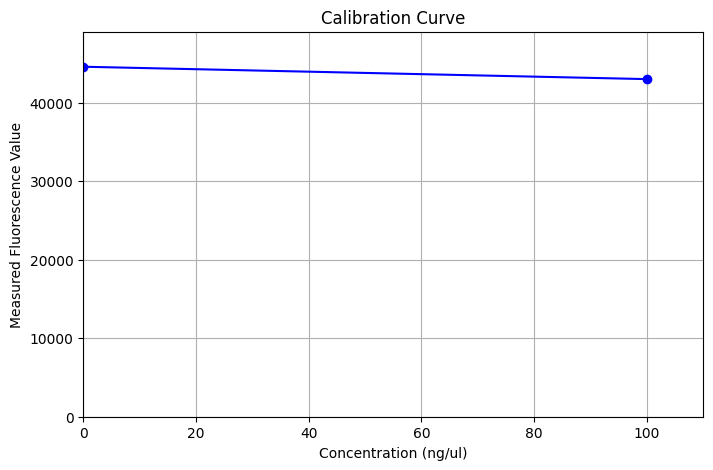

In [54]:
for col in [col for col in table_data.columns if col != 'Row_Label']:
    table_data[col] = table_data[col].apply(calculate_concentration)

print("Here is the data with calculated concentrations:")
display(table_data)

x_values = [zero_point_concentration, point_concentration]
y_values = [zero_point_value, point_value]

plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, color='blue', linestyle='-', marker='o')
plt.xlim(0, max(x_values) * 1.1)
plt.ylim(0, max(y_values) * 1.1)
plt.title('Calibration Curve')
plt.ylabel('Measured Fluorescence Value')
plt.xlabel('Concentration (ng/ul)')
plt.grid(True)
plt.show()

### Clean up
This part of the code removes all negative values from the data frame, since they are not useful for analysis.

In [55]:
table_data1 = table_data.where(table_data.select_dtypes(include='number') >= 0)
new_table = table_data1[table_data1 >= 0].fillna('')
new_table['Row_Label'] = table_data['Row_Label']
display(new_table)

,Row_Label,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,A,,,,376.06,,200.0,,,,...,546.93,314.0,,395.95,412.92,528.06,148.45,450.92,507.03,520.58
1,B,543.76,361.75,639.52,469.66,410.89,391.51,289.04,,528.94,...,244.46,412.16,16.72,238.13,452.18,329.96,616.47,573.27,631.67,813.93
2,C,,,,576.06,,581.13,,99.81,,...,256.36,312.22,246.74,581.25,543.13,495.76,674.86,696.14,666.37,728.69
3,D,624.45,428.37,543.0,540.60,499.56,702.47,592.27,382.9,709.44,...,623.56,374.29,323.75,451.04,393.67,442.18,424.95,582.01,518.05,741.10
4,E,,,,291.58,,395.19,,87.65,,...,433.06,375.55,90.69,404.56,514.38,622.55,530.59,404.56,488.66,658.14
5,F,594.93,452.82,616.47,329.58,404.81,702.34,705.89,275.11,500.57,...,559.59,472.45,359.34,554.78,395.82,467.38,477.64,346.93,476.76,631.54
6,G,,,,610.01,,456.24,,336.8,,...,693.98,343.76,393.03,477.64,533.63,543.38,499.30,436.48,462.06,439.27
7,H,233.19,389.99,515.26,537.18,589.61,508.55,563.52,359.21,556.68,...,608.87,124.76,223.69,365.55,571.37,394.55,547.06,476.63,316.53,526.16
8,I,,,,239.14,,237.11,,218.87,,...,160.61,74.35,329.7,196.07,262.82,392.91,365.04,365.42,402.66,303.86
9,J,439.52,349.84,311.59,440.53,399.62,151.74,305.76,341.99,550.98,...,664.09,429.39,483.98,542.37,498.8,280.30,504.75,551.11,412.79,661.56


### Heatmap
This code generates a heatmap of the relevant concentrations. It uses a color scale, with lighter shades for lower concentration and darker shades for higher concentrations.

/tmp/ipykernel_1123/1830778896.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  harvest = new_table[col_labels].replace('', np.nan).astype(float).values


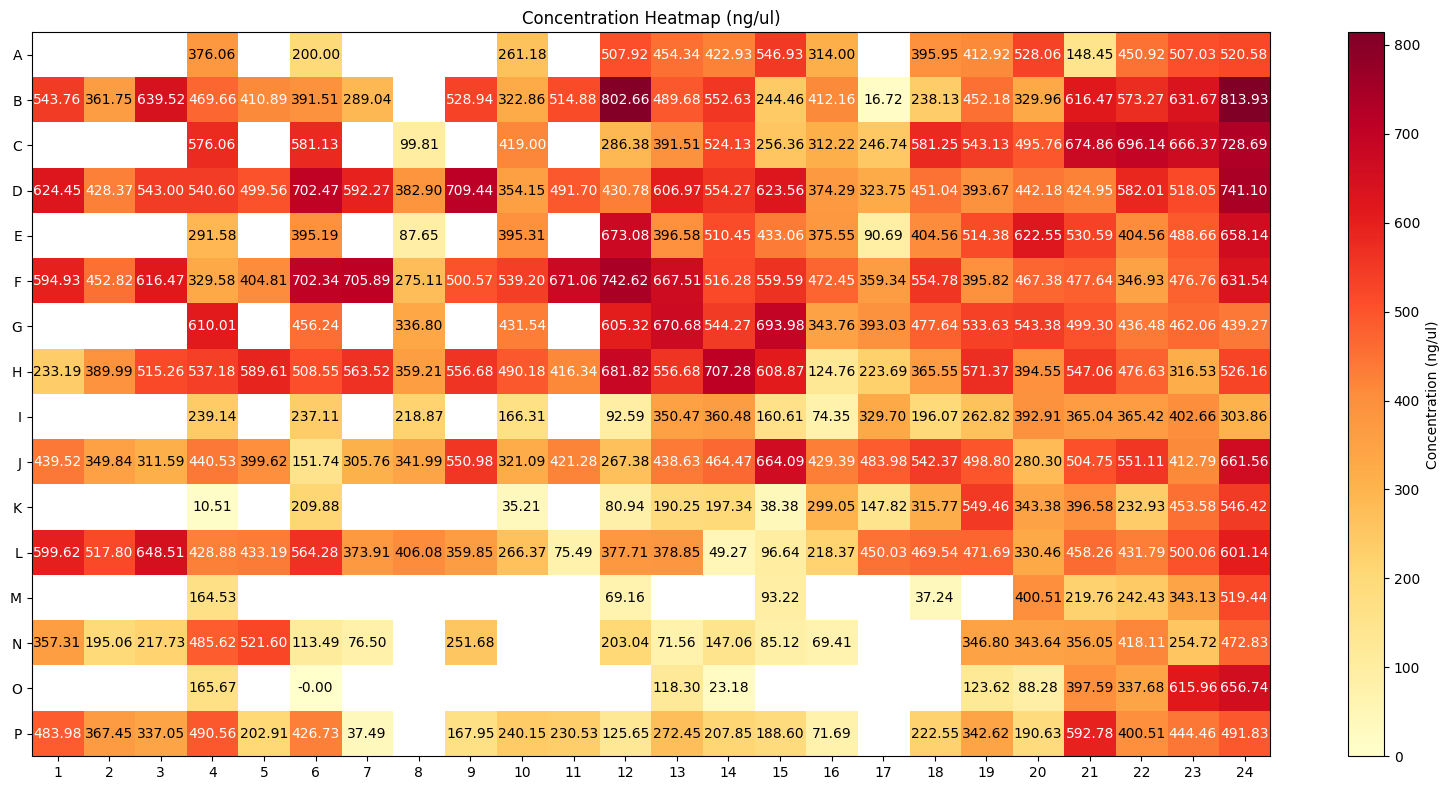

In [56]:
# Separate Row_Label and convert the rest to numeric
row_labels = new_table['Row_Label'].tolist()
col_labels = [col for col in new_table.columns if col != 'Row_Label']

# Convert to float matrix (empty strings become NaN)
harvest = new_table[col_labels].replace('', np.nan).astype(float).values

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(harvest, aspect='auto', cmap='YlOrRd')

# Set ticks and labels
ax.set_xticks(range(len(col_labels)), labels=col_labels)
ax.set_yticks(range(len(row_labels)), labels=row_labels)

# Add colorbar
plt.colorbar(im, ax=ax, label='Concentration (ng/ul)')

# Loop over data and create text annotations
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        value = harvest[i, j]
        if not np.isnan(value):
          text_color = "white" if value > np.nanmax(harvest) / 2 else "black"
          text = ax.text(j, i, f"{value:.2f}",
                          ha="center", va="center", color= text_color, fontsize=10)

ax.set_title("Concentration Heatmap (ng/ul)")
fig.tight_layout()
plt.show()

### Excel table
This code lets the user export the cleaned data frame as an Excel file for further analysis specific to the experiment. The file is available in the Colab document under the name “result.”

In [57]:
if not os.path.exists('result'):
    os.mkdir('result')
data_table = new_table.copy()
data_table['Row_Label'] = new_table['Row_Label']
data_table.to_excel('result/data_table.xlsx', index=False)

### CSV List
This final part of the code generates a CSV file listing all the well positions with their corresponding concentrations. The csv list is available in the Colab document in the file named “result.” To view the full list, open it in the Colab document.

In [58]:
rows = []
for i, row in new_table.iterrows():
    row_label = row['Row_Label']
    for col in [col for col in new_table.columns if col != 'Row_Label']:
        value = row[col]
        if pd.notna(value) and value != '':
            rows.append({'Well': f"{row_label}{col}", 'Concentration_ng_ul': value})

csv_df = pd.DataFrame(rows)
csv_df.to_csv('result/well_concentrations.csv', index=False)
print(f"Saved {len(csv_df)} wells to CSV!")
display(csv_df)

Saved 302 wells to CSV!


,Well,Concentration_ng_ul
0,A4,376.06
1,A6,200.00
2,A10,261.18
3,A12,507.92
4,A13,454.34
...,...,...
297,P20,190.63
298,P21,592.78
299,P22,400.51
300,P23,444.46
